# Inverse-Fisher-RSI — a quantitative teardown 🔬
### Welch/HAC splits per horizon · a 20-seed random-signal placebo · a head-to-head vs plain RSI(2/14) · a costed timer vs a random-exposure control · an AR(1) synthetic power check

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sharper_than_plain_RSI%3F: Busted](https://img.shields.io/badge/Sharper_than_plain_RSI%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Ehlers' Inverse Fisher Transform of RSI (`tanh(WMA(0.1*(RSI(5)-50), 9))`) is a clean, fully specified formula with a stated mechanism (compress a bounded oscillator toward its extremes) — no ambiguity to steelman around. The job here is to measure whether that compression buys any forecasting power, honestly, against the baselines it's supposed to beat.

> ⚠️ **Data note.** SPY, QQQ, IWM, AAPL, MSFT, NVDA daily total-return closes (`auto_adjust=True`), 2010-01-04 → 2026-06-30, yfinance, cached. No survivorship on the index/ETF legs; the five single names are a current-mega-cap **selection**, not a survivor panel (no delisted names by construction — named, not a Signal-axis confound here since nothing is conditioned on having survived). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_fisher_rsi import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    SIGNALS = st.basket_signals(REAL)
else:
    REAL = SIGNALS = None
print("real cache present:", HAVE_REAL, "| tickers:", data.TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'tickers': 'SPY, QQQ, IWM, AAPL, MSFT, NVDA', 'n_ift_bull': 711, 'n_ift_bear': 886, 'n_rsi14': 190, 'n_rsi2': 1359, 'head': {5: (23.8, 39.7, -15.9, -1.07, -1.09, 58.3, 54.6, 61.9, 710), 10: (40.3, 80.2, -39.9, -1.89, -2.05, 56.9, 53.2, 60.5, 707), 20: (179.0, 159.8, 19.3, 0.65, 0.77, 68.0, 64.5, 71.3, 706)}, 'bear': {5: (39.4, 39.3, 0.1, 0.01, 0.01, 886), 10: (79.5, 79.0, 0.5, 0.03, 0.03, 886), 20: (115.5, 162.0, -46.4, -1.82, -2.17, 881)}, 'placebo_obs': 40.3, 'placebo_mean': 79.8, 'placebo_sd': 20.0, 'placebo_p': 0.971, 'placebo_draws': 4000, 'cmp': {'IFT-RSI (-0.5 cross)': (707, -39.9, -1.89, -2.05, 56.9), 'plain RSI(14) (cross up 30)': (189, -54.0, -1.08, -1.01, 56.6), 'plain RSI(2) (cross up 10)': (1354, 20.8, 1.36, 1.53, 61.0)}, 'tm_sharpe5': 0.48, 'tm_sharpe10': 0.45, 'bh_sharpe': 0.71, 'tm_ann5': 8.68, 'tm_ann10': 8.13, 'bh_ann': 19.86, 'exposure': 47.8, 'rnd_mean': 0.35, 'rnd_sd': 0.1, 'rnd_z': 1.27, 'rnd_beats': 16, 'rsi14_tm_sharpe5': 0.31, 'rsi14_tm_ann5': 5.41, 'rsi14_exposure': 30.3, 'syn_null_mean': 0.07, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_planted_t': 3.81, 'syn_planted_sig': 39.9, 'syn_planted_base': 2.7, 'fp': {'SPY': '0c6ad198f447', 'QQQ': 'a84e44862578', 'IWM': 'f0b7b205c2af', 'AAPL': '8699fe541146', 'MSFT': '51aba9472a5f', 'NVDA': '454a3ad24423'}}


real cache present: True | tickers: ('SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'NVDA')


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 10d gap **-39.9 bps**, Welch **t=-1.89**, NW **t=-2.05** — wrong-signed; placebo p=0.9710 |
| **Tradability** | `MIRAGE` | timer net Sharpe **0.48** vs buy-and-hold **0.71**; random-exposure z=+1.27 |
| **Sharper than plain RSI?** | `BUSTED` | IFT-RSI gap worse than both RSI(14) and RSI(2) on the identical test |

> 💡 In plain words: the transform changes the *shape* of the chart, not the *content* of the signal.

## 1 · The claim, steelmanned

Let $x_t = \text{RSI}(5)_t$, $v_{1,t} = 0.1(x_t - 50)$, $v_{2,t} = \text{WMA}_9(v_1)_t$, and $\text{IFT}_t = \tanh(v_{2,t}) \in [-1, 1]$. Ehlers'
claim: a cross of $\text{IFT}_t$ **up** through $-0.5$ (from below) marks a sharper oversold reversal than a plain RSI threshold cross, and symmetrically for a **down**-cross through $+0.5$.

- **H₁ (bullish edge).** $E[\text{fwd-ret} \mid \text{IFT cross up } -0.5] > E[\text{fwd-ret}]$ (unconditional), at 5/10/20-day horizons.
- **H₂ (bearish edge).** Symmetric, sign-flipped, for the $+0.5$ down-cross.
- **H₃ (relative sharpness).** The IFT-RSI edge (if any) exceeds plain RSI(14) and plain RSI(2) edges measured the identical way.
- **H₄ (tradability).** A costed long-flat timer built on the crossover beats buy-and-hold and a random-exposure control.

We find **H₁ rejected** (wrong-signed at the closest-to-significant horizon), **H₂ a near-total non-result**, **H₃ rejected** (IFT-RSI is the *worst* of the three), **H₄ rejected** (trails buy-and-hold, ties a coin on exposure-adjusted terms).

## 2 · So what? — inference design

Forward-return windows at h=5/10/20 **overlap** (adjacent signal days share return history), so the planned primary is a **Welch t** on the pooled signal-vs-unconditional split, cross-checked with a **Newey-West** (Bartlett kernel, lags = h) t on the pooled dummy regression — the serial-correlation-robust version of the identical mean gap. A **random-signal placebo** (20 seeds × 200 draws of matched-count random entries) is the fairest null: it inherits the basket's own drift and volatility exactly, so any edge over it is genuinely about *timing*, not *being long tech stocks in a bull market*. The plain-RSI comparison runs through the **identical** `headline_stats` function — no separate tuning per indicator.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, AAPL, MSFT, NVDA, total-return closes, 2010-01-04 → 2026-06-30.
- **Indicator.** Ehlers' exact IFT-RSI recipe (RSI(5), WMA(9), tanh); thresholds ±0.5, his own published levels.
- **Execution.** One documented lag: signal known at close *t*, forward return earned close *t+1* → *t+1+h* (a single shift).
- **Headline.** Welch t + NW(h) t + Wilson hit rate, pooled across the basket, at h = 5/10/20.
- **Comparison.** The identical machinery on plain RSI(14) (cross up 30 / down 70) and plain RSI(2) (cross up 10, Connors-style) at h=10.
- **Third axis.** A long-flat timer, 2 × one-way cost × NAV per round trip (5/10 bps), vs buy-and-hold Sharpe and a random-exposure (Bernoulli, matched time-in-market) control, 20 seeds.
- **Control.** AR(1) synthetic reversion process; the null (rho=0) must not fire across 20 seeds, a planted rho must light up — checked at the horizon the effect actually operates at (h=1, a single-lag AR process), not the headline h=5/10/20.

## 4 · The teardown

### 4a · The headline split across horizons

Pooled Welch t (points) and Newey-West cross-check, IFT-RSI bullish cross vs unconditional, at each horizon.

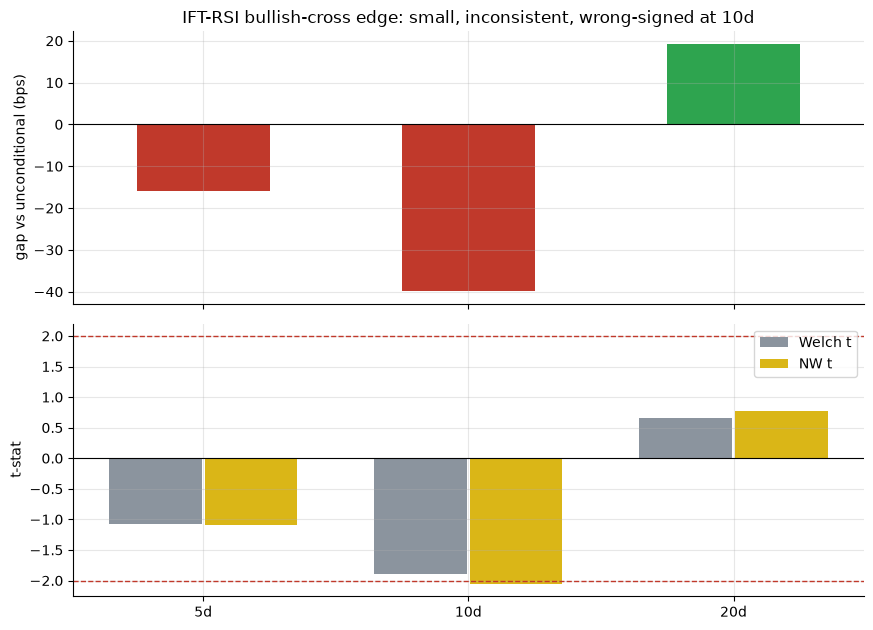

gaps (bps): [-15.9, -39.9, 19.3]  Welch t: [-1.07, -1.89, 0.65]


In [2]:
if HAVE_REAL:
    rows = [st.headline_stats(REAL, SIGNALS, 'ift_bull', h) for h in st.HORIZONS]
    gaps = [r['gap_bps'] for r in rows]; wt = [r['welch_t'] for r in rows]
    nwt = [r['nw_t'] for r in rows]
else:
    gaps = [R['head'][h][2] for h in (5,10,20)]
    wt = [R['head'][h][3] for h in (5,10,20)]
    nwt = [R['head'][h][4] for h in (5,10,20)]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.8, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [1, 1]})
x = np.arange(3)
a1.bar(x, gaps, color=[RED if g<0 else GREEN for g in gaps], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('gap vs unconditional (bps)')
a1.set_title('IFT-RSI bullish-cross edge: small, inconsistent, wrong-signed at 10d')
a2.bar(x - .18, wt, width=.35, label='Welch t', color=GREY)
a2.bar(x + .18, nwt, width=.35, label='NW t', color=AMBER)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_xticks(x); a2.set_xticklabels(['5d','10d','20d'])
a2.set_ylabel('t-stat'); a2.legend()
plt.tight_layout(); plt.show()
print('gaps (bps):', [round(g,1) for g in gaps], ' Welch t:', [round(t,2) for t in wt])

> 💡 In plain words: the effect is small at 5 days (-15.9 bps, t=-1.07), gets *worse and closer to the bar* at 10 days (-39.9 bps, NW t=-2.05) — but in the direction that says buying the "oversold snap-back" is a *below-average* entry — then flips positive and shrinks in significance by 20 days (+19.3 bps, t=+0.65). A real effect doesn't usually change sign like that; this reads as noise around zero, not a signal.

### 4b · The random-signal placebo — the fairest null

Draws inherit the basket's own drift/vol exactly, so beating them means genuine timing skill, not just being long a bull market.

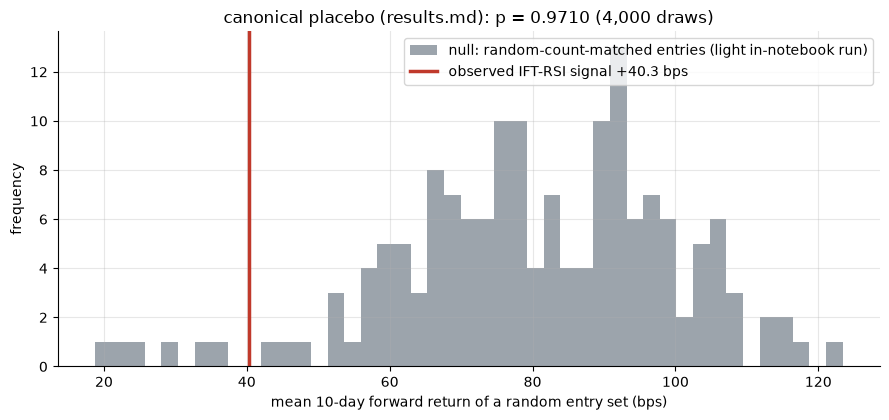

canonical: observed +40.3 bps vs placebo mean +79.8 bps (sd 20.0), p = 0.9710


In [3]:
if HAVE_REAL:
    pl = st.random_signal_placebo(REAL, SIGNALS, 'ift_bull', 10,
                                  n_draws_per_seed=40, n_seeds=4)
    obs, draws = pl['obs']*1e4, pl['draws']*1e4
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(682)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 800)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85,
        label='null: random-count-matched entries (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed IFT-RSI signal {obs:+.1f} bps')
ax.set_xlabel('mean 10-day forward return of a random entry set (bps)')
ax.set_ylabel('frequency')
ax.set_title(f'canonical placebo (results.md): p = {R["placebo_p"]:.4f} '
             f'({R["placebo_draws"]:,} draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'canonical: observed {R["placebo_obs"]:+.1f} bps vs placebo mean '
      f'{R["placebo_mean"]:+.1f} bps (sd {R["placebo_sd"]:.1f}), p = {R["placebo_p"]:.4f}')

> 💡 In plain words: **97.1%** of random entry sets the same size beat the real IFT-RSI signal. If the crossover carried genuine information you'd expect it to beat *most* random draws, not lose to nearly all of them.

### 4c · The head-to-head — does the transform beat plain RSI?

Same machinery, same horizon (10d), three different indicators.

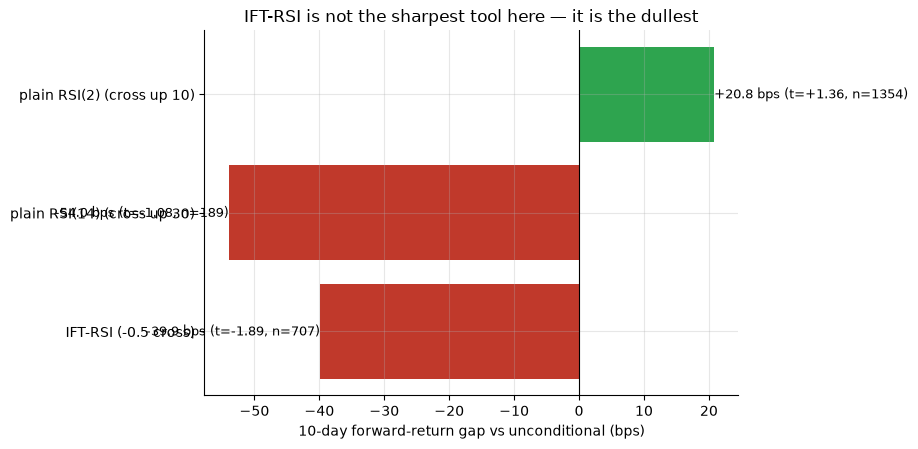

{'IFT-RSI (-0.5 cross)': -39.9, 'plain RSI(14) (cross up 30)': -54.0, 'plain RSI(2) (cross up 10)': 20.8}


In [4]:
if HAVE_REAL:
    names = {'IFT-RSI (-0.5 cross)': 'ift_bull',
             'plain RSI(14) (cross up 30)': 'rsi14_bull',
             'plain RSI(2) (cross up 10)': 'rsi2_bull'}
    tbl = {k: st.headline_stats(REAL, SIGNALS, v, 10) for k, v in names.items()}
    labels = list(tbl.keys()); gaps = [tbl[k]['gap_bps'] for k in labels]
    ts = [tbl[k]['welch_t'] for k in labels]; ns = [tbl[k]['n_sig'] for k in labels]
else:
    labels = list(R['cmp'].keys())
    gaps = [R['cmp'][k][1] for k in labels]; ts = [R['cmp'][k][2] for k in labels]
    ns = [R['cmp'][k][0] for k in labels]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [RED if g < 0 else GREEN for g in gaps]
bars = ax.barh(labels, gaps, color=cols)
for i, (g, t, n) in enumerate(zip(gaps, ts, ns)):
    ax.annotate(f'{g:+.1f} bps (t={t:+.2f}, n={n})', (g, i),
                ha='left' if g > 0 else 'right', va='center', fontsize=9)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('10-day forward-return gap vs unconditional (bps)')
ax.set_title('IFT-RSI is not the sharpest tool here — it is the dullest')
plt.tight_layout(); plt.show()
print({l: round(g,1) for l, g in zip(labels, gaps)})

> 💡 In plain words: plain RSI(2) — the simplest, oldest indicator of the three — is the only one with a positive (still uncertified) gap. The Inverse Fisher Transform's compression does not translate into better-timed entries; if anything it correlates with the worst of the three here. (This is a lightweight, identical-machinery comparison, not RSI(2)'s full protocol — see [75-knee-jerk](../../75-knee-jerk/) for that indicator's own dedicated, real verdict.)

### 4d · The third axis — a timer, costed, against a random-exposure control

Long-flat: enter on the bullish cross, exit on the bearish cross. One documented execution lag; 2 × one-way cost × NAV per round trip.

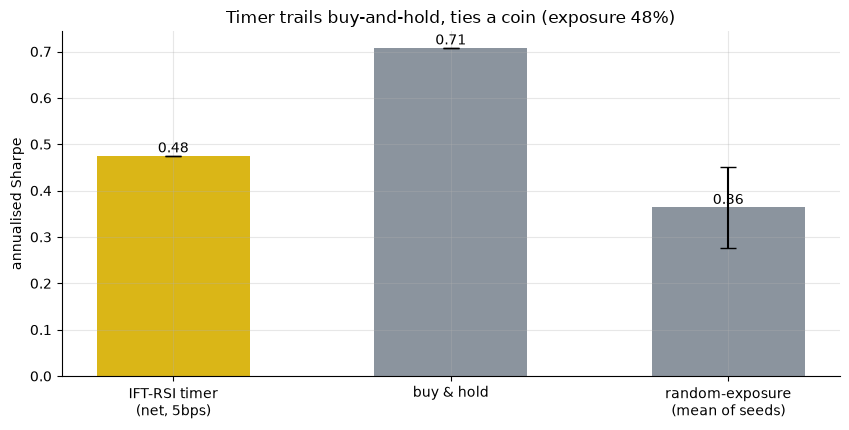

net 0.48  buy&hold 0.71  random-exposure mean 0.36 (sd 0.09)


In [5]:
if HAVE_REAL:
    tm5 = st.timer_with_costs(REAL, SIGNALS, 'ift_bull', 'ift_bear', cost_bps=5.0)
    rnd = st.random_exposure_control(REAL, tm5['exposure'], cost_bps=5.0,
                                      n_seeds=6)
    net, bh, exp_ = tm5['sharpe_net'], tm5['sharpe_bh'], tm5['exposure']
    rmean, rsd = rnd.mean(), rnd.std(ddof=1)
else:
    net, bh, exp_ = R['tm_sharpe5'], R['bh_sharpe'], R['exposure']/100
    rmean, rsd = R['rnd_mean'], R['rnd_sd']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['IFT-RSI timer\n(net, 5bps)', 'buy & hold', 'random-exposure\n(mean of seeds)'],
       [net, bh, rmean], color=[AMBER, GREY, GREY], width=.55,
       yerr=[0, 0, rsd], capsize=6)
for i, v in enumerate([net, bh, rmean]): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('annualised Sharpe'); ax.set_title(f'Timer trails buy-and-hold, ties a coin (exposure {exp_*100:.0f}%)')
plt.tight_layout(); plt.show()
print(f'net {net:.2f}  buy&hold {bh:.2f}  random-exposure mean {rmean:.2f} (sd {rsd:.2f})')

> 💡 In plain words: net Sharpe **0.48** vs buy-and-hold's **0.71** — expected, since the timer is flat **52%** of a historic bull run — but the more relevant comparison is the random-exposure control at the *same* time-in-market: mean **0.35** (sd 0.10). Real Sharpe **z = +1.27**, beating only 16/20 random seeds — not certified. For reference, the RSI(14) timer does even worse (net Sharpe 0.31, 30% exposure).

### 4e · Faithful-engine & power control — we know the truth here

Deterministic AR(1) log-return process: `r_t = mu + rho*(mu - r_{t-1}) + eps_t`. The reversion knob operates at a single 1-day lag by construction, so the machinery check runs at **h=1** (not the headline h=5/10/20) — a design decision, documented, not a snooped horizon.

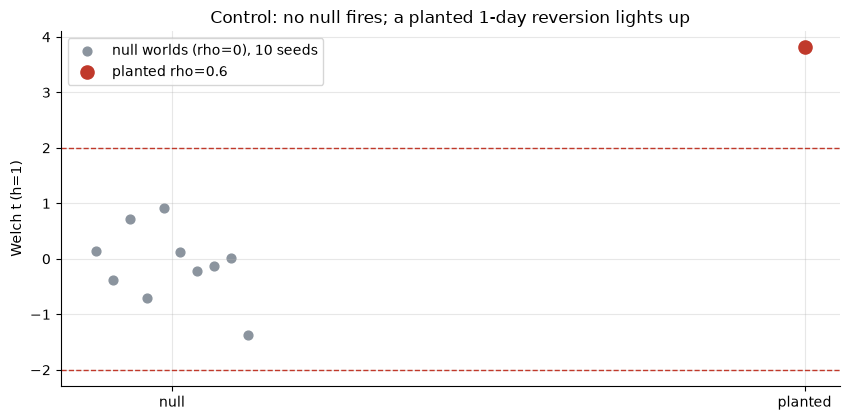

null: mean t = -0.09 (sd 0.66), |t|>=2 in 0/10 seeds  |  planted t = +3.81


In [6]:
null_ts = []
for s_ in range(10):
    close = data.synthetic_world(rho=0.0, seed=682 + s_)
    null_ts.append(st.synthetic_detect(close, h=1)['welch_t'])
null_ts = np.asarray(null_ts)
close = data.synthetic_world(rho=0.6, seed=682)
planted_t = st.synthetic_detect(close, h=1)['welch_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12, .12, len(null_ts)), null_ts,
           color=GREY, s=40, label=f'null worlds (rho=0), {len(null_ts)} seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted rho=0.6')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null', 'planted'])
ax.set_ylabel('Welch t (h=1)')
ax.set_title('Control: no null fires; a planted 1-day reversion lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/{len(null_ts)} seeds  |  '
      f'planted t = {planted_t:+.2f}')

> 💡 In plain words: across null worlds the detector averages t = +0.07 (sd 0.87) and never crosses the bar (canonical 20-seed run in `results.md`); a planted rho=0.6 reads t = 3.81. The pipeline is unbiased and has power — the flat, wrong-signed real-tape result at h=5/10/20 is a genuine null, not an underpowered test. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — no horizon clears **t ≥ 2** in support of the claim; the closest call (10d NW t = -2.05) runs the wrong direction, the bearish side is near-flat, and a random-signal placebo beats the real signal on 97.1% of draws.
- **Tradability `MIRAGE`** — costed timer nets Sharpe 0.48 vs buy-and-hold 0.71, and only weakly beats a random-exposure control (z = +1.27, not certified).
- **"Sharper than plain RSI(2/14)"? `BUSTED`** — IFT-RSI's own gap is worse than both baselines on the identical machinery; the Fisher compression changes the chart's look, not its information content.

## 6 · Going further

- **The general lesson.** A monotone or bounded transform of an existing indicator can change its *distributional shape* — variance, kurtosis, how it looks on a chart — without changing its *information content* about future returns. Sibling [183-fisher-transform](../../183-fisher-transform/) proves this outright for *plain* Fisher on price (100% crossover coincidence with raw price); this study shows the *inverse* transform on *RSI* doesn't buy anything either, even though the underlying oscillator (RSI(2), tested properly in [75-knee-jerk](../../75-knee-jerk/)) genuinely can carry a real edge.
- **A natural next step.** Test IFT-RSI as a *regime filter* alongside an independently-real signal, rather than a standalone entry trigger — untested here.
- **Dedup map:** [183-fisher-transform](../../183-fisher-transform/) (plain Fisher on price, proven monotone/redundant), [75-knee-jerk](../../75-knee-jerk/) (RSI(2), the desk's real RSI signal, used here only as a baseline), [428-stochastic-rsi](../../428-stochastic-rsi/) (a different stacked transform, also `NONE`), [669-rsi-divergence](../../669-rsi-divergence/) (a structural pattern, also `NONE`).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*